# Question Classification with Sentence Embeddings — Codex-Style Embedding Model Comparison

This rewritten notebook keeps the codex-style **linear supervised learning pipeline**, but changes the **analysis goal**:

1. Build a fixed train / test / holdout setup  
2. Embed each question into a feature vector  
3. Learn the same kind of linear multiclass PyTorch model on top of each embedding space  
4. Compare the two embedding models head-to-head  
5. Identify where each embedding succeeds, where it fails, and which classes each model struggles with  
6. Use confusion matrices, per-class F1, disagreement examples, and coarse-category analysis to diagnose model deficiencies

So the main question is no longer **“does performance improve if we change the split or add more data?”**  
Instead, it is **“what strengths and weaknesses do the embedding models show relative to each other when the downstream classifier is held fixed?”**


## Why this version matches the codex better

The codex teaches supervised learning as:
- define the input-output learning task,
- convert data into tensors,
- define a **linear PyTorch model**,
- define a loss function,
- train using gradient descent,
- and evaluate generalization on independent test data.

So in this notebook, the main change is:

- **Old approach:** sentence embeddings + `sklearn.LogisticRegression`
- **New approach:** sentence embeddings + **PyTorch `nn.Sequential(nn.Linear(d, k))`**

That mirrors the codex idea of learning a linear map from an input vector in `R^d` to an output vector in `R^k`, where `k` is the number of classes. The codex also uses one-hot targets and `argmax` at inference time. fileciteturn1file0 fileciteturn4file2


In [35]:
!pip install -q sentence-transformers torch scikit-learn pandas numpy matplotlib seaborn


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [36]:
import copy
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

from sentence_transformers import SentenceTransformer
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    confusion_matrix,
    log_loss,
)

plt.rcParams["figure.figsize"] = (10, 6)
sns.set_context("talk")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)


## Step 1: Load and inspect the data

In [37]:
train_df = pd.read_csv('question_classificatrion/question_classification_dataset/train.csv')
test_df = pd.read_csv('question_classificatrion/question_classification_dataset/test.csv')

print("Provided train shape:", train_df.shape)
print("Provided test shape:", test_df.shape)
display(train_df.head())

print("\nNumber of coarse labels:", train_df["label-coarse"].nunique())
print("Number of fine labels:", train_df["label-fine"].nunique())

Provided train shape: (5452, 3)
Provided test shape: (500, 3)


,label-coarse,label-fine,text
0,0,0,How did serfdom develop in and then leave Russ...
1,1,1,What films featured the character Popeye Doyle ?
2,0,0,How can I find a list of celebrities ' real na...
3,1,2,What fowl grabs the spotlight after the Chines...
4,2,3,What is the full form of .com ?



Number of coarse labels: 6
Number of fine labels: 47


## Step 2: Recombine and create one fixed random 25 / 25 / 50 split

The codex emphasizes:
- training data is used to fit the model,
- test data is used to check whether the learned relationship generalizes,
- and truly unseen data should stay independent until the end. fileciteturn1file4

Here, the split is just a **controlled experimental setup**.  
We are **not** treating the train / test / holdout ratio itself as the main experimental variable.

Instead, we keep one fixed **25% train / 25% test / 50% holdout** split so both embedding models are judged under the **same downstream conditions**, which makes the comparison fairer.


In [38]:
full_df = pd.concat([train_df, test_df], ignore_index=True).reset_index(drop=True)
print("Combined shape:", full_df.shape)

focused_df = full_df.copy()

train_test_df, holdout_df = train_test_split(
    focused_df,
    test_size=0.50,
    random_state=RANDOM_STATE,
    stratify=focused_df["label-fine"]
)

train_split_df, test_split_df = train_test_split(
    train_test_df,
    test_size=0.50,
    random_state=RANDOM_STATE,
    stratify=train_test_df["label-fine"]
)

print("Train shape:", train_split_df.shape)
print("Test shape:", test_split_df.shape)
print("Holdout shape:", holdout_df.shape)

print("\nTrain fine-label distribution:")
display(train_split_df["label-fine"].value_counts().sort_index())

print("\nTest fine-label distribution:")
display(test_split_df["label-fine"].value_counts().sort_index())

print("\nHoldout fine-label distribution:")
display(holdout_df["label-fine"].value_counts().sort_index())

Combined shape: (5952, 3)
Train shape: (1488, 3)
Test shape: (1488, 3)
Holdout shape: (2976, 3)

Train fine-label distribution:


label-fine
0      70
1      51
2      32
3      20
4     254
5      49
6       6
7     136
8      66
9      50
10     15
11     18
12     83
13     93
14    201
15      2
16      1
17     27
18     40
19     12
20     25
21     37
22      4
23     27
24      6
25     19
26     11
27     20
28     14
29     16
30      4
31     10
32      3
33      3
34      4
35      4
36      6
37      4
38      8
39      2
40     13
41      3
42      3
43      2
44      8
45      4
46      2
Name: count, dtype: int64


Test fine-label distribution:


label-fine
0      69
1      52
2      32
3      19
4     255
5      49
6       7
7     136
8      66
9      49
10     14
11     18
12     83
13     93
14    202
15      2
16      1
17     27
18     39
19     13
20     25
21     37
22      5
23     26
24      6
25     18
26     12
27     21
28     14
29     15
30      5
31      9
32      3
33      3
34      4
35      4
36      7
37      5
38      7
39      2
40     12
41      3
42      3
43      1
44      8
45      4
46      3
Name: count, dtype: int64


Holdout fine-label distribution:


label-fine
0     139
1     104
2      64
3      39
4     508
5      97
6      13
7     272
8     133
9      98
10     29
11     37
12    165
13    186
14    404
15      5
16      2
17     53
18     79
19     25
20     50
21     73
22      9
23     52
24     12
25     37
26     23
27     42
28     28
29     32
30      9
31     20
32      7
33      5
34      9
35      7
36     13
37      9
38     15
39      5
40     25
41      7
42      5
43      3
44     15
45      7
46      5
Name: count, dtype: int64

## Step 3: Choose two embedding models

We still use sentence embeddings, but now the embedding becomes the **input vector** `x in R^d` for the linear supervised learner.

That is exactly the codex idea near the end: first compute an embedding, then learn a linear classifier on top of the embedding space rather than on raw text directly. fileciteturn1file3


In [39]:
embedding_models = [
    "all-MiniLM-L6-v2",
    "paraphrase-MiniLM-L6-v2",
]

X_train_text = train_split_df["text"].tolist()
X_test_text = test_split_df["text"].tolist()
X_holdout_text = holdout_df["text"].tolist()

y_train_labels = train_split_df["label-fine"].to_numpy()
y_test_labels = test_split_df["label-fine"].to_numpy()
y_holdout_labels = holdout_df["label-fine"].to_numpy()

y_test_coarse = test_split_df["label-coarse"].to_numpy()
y_holdout_coarse = holdout_df["label-coarse"].to_numpy()

class_names = sorted(focused_df["label-fine"].unique().tolist())
class_to_idx = {label: idx for idx, label in enumerate(class_names)}
idx_to_class = {idx: label for label, idx in class_to_idx.items()}

class_names_coarse = sorted(focused_df["label-coarse"].unique().tolist())
fine_to_coarse = (
    focused_df[["label-fine", "label-coarse"]]
    .drop_duplicates()
    .set_index("label-fine")["label-coarse"]
    .to_dict()
)

print("Fine classes:", class_names)
print("Number of fine classes:", len(class_names))
print("Coarse classes:", class_names_coarse)

Fine classes: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46]
Number of fine classes: 47
Coarse classes: [0, 1, 2, 3, 4, 5]


## Helper functions

The most important codex-aligned pieces are:

- `model_fit_pytorch(...)`: train a model with SGD / gradient descent  
- `nn.Sequential(nn.Linear(d, k))`: define the linear multiclass map  
- one-hot labels for the targets  
- `argmax(...)`: convert model outputs back into predicted class labels at inference time. fileciteturn1file2 fileciteturn4file0


In [40]:
def embed_texts(model_name, texts):
    model = SentenceTransformer(model_name)
    start = time.time()
    embeddings = model.encode(texts, convert_to_numpy=True, show_progress_bar=False)
    elapsed = time.time() - start
    return embeddings, elapsed


def labels_to_index(labels, class_to_idx):
    return np.array([class_to_idx[label] for label in labels], dtype=np.int64)


def one_hot_encode(label_indices, num_classes):
    return np.eye(num_classes, dtype=np.float32)[label_indices]


def make_multiclass_tensors(X_np, y_labels, class_to_idx):
    y_idx = labels_to_index(y_labels, class_to_idx)
    y_onehot = one_hot_encode(y_idx, len(class_to_idx))

    X_tensor = torch.tensor(X_np, dtype=torch.float32).reshape(X_np.shape)
    Y_onehot_tensor = torch.tensor(y_onehot, dtype=torch.float32).reshape(y_onehot.shape)
    y_idx_tensor = torch.tensor(y_idx, dtype=torch.int64)

    return X_tensor, Y_onehot_tensor, y_idx_tensor, y_idx


def model_fit_pytorch(x_train, y_train, model, loss_criterion=nn.MSELoss(), epochs=1000, lr=0.01, log_interval=100):
    optimizer = optim.SGD(model.parameters(), lr=lr)
    loss_history = []

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()

        y_pred = model(x_train)
        loss = loss_criterion(y_pred, y_train)

        loss.backward()
        optimizer.step()

        loss_history.append(loss.item())

        if log_interval and epoch % log_interval == 0:
            print(f"Epoch [{epoch}/{epochs}] | Loss: {loss_history[-1]:.6f}")

    return model, loss_history


def pytorch_model_multiclass_inference(model, X_tensor):
    model.eval()
    with torch.no_grad():
        Y_pred = model(X_tensor)
        pred_idx = torch.argmax(Y_pred, dim=1).detach().cpu().numpy()
    return Y_pred.detach().cpu().numpy(), pred_idx


def predict_proba_from_scores(score_matrix):
    # Convert linear outputs into class probabilities for log-loss evaluation.
    scores = torch.tensor(score_matrix, dtype=torch.float32)
    probs = torch.softmax(scores, dim=1).detach().cpu().numpy()
    return probs


def evaluate_multiclass_model(model, X_tensor, y_idx, split_name, class_names):
    raw_scores, pred_idx = pytorch_model_multiclass_inference(model, X_tensor)
    probs = predict_proba_from_scores(raw_scores)

    row = {
        "split": split_name,
        "accuracy": accuracy_score(y_idx, pred_idx),
        "macro_f1": f1_score(y_idx, pred_idx, average="macro"),
        "log_loss": log_loss(y_idx, probs, labels=np.arange(len(class_names))),
    }
    pred_labels = np.array([class_names[i] for i in pred_idx], dtype=object)
    return row, pred_idx, pred_labels, probs


def per_class_f1_df(y_true_idx, y_pred_idx, class_names, model_name, stage):
    f1_scores = f1_score(y_true_idx, y_pred_idx, average=None, labels=np.arange(len(class_names)), zero_division=0)
    return pd.DataFrame({
        "label-fine": class_names,
        "f1-score": f1_scores,
        "model": model_name,
        "stage": stage,
    })


def plot_metric_comparison(df, metric, title):
    plt.figure(figsize=(10, 6))
    sns.barplot(data=df, x="model", y=metric, hue="split")
    plt.title(title)
    plt.ylabel(metric)
    plt.xticks(rotation=20, ha="right")
    plt.tight_layout()
    plt.show()


def plot_conf_mat(y_true, y_pred, labels, title, save_path=None):
    cm = confusion_matrix(y_true, y_pred, labels=labels, normalize="true") * 100

    plt.figure(figsize=(max(7, 0.6 * len(labels)), max(6, 0.55 * len(labels))))
    sns.heatmap(
        cm,
        annot=True,
        fmt=".1f",
        cmap="Blues",
        xticklabels=labels,
        yticklabels=labels,
        linewidths=0.5,
        linecolor="white",
    )
    plt.xlabel("Predicted")
    plt.ylabel("True (row %)")
    plt.title(title)
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()

    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(save_path, dpi=200, bbox_inches="tight")

    plt.show()


def build_linear_multiclass_model(input_dim, output_dim):
    return nn.Sequential(nn.Linear(input_dim, output_dim))


def train_one_embedding_pipeline(model_name, X_train_text, X_test_text, X_holdout_text, y_train_labels, y_test_labels, y_holdout_labels, class_to_idx, class_names, epochs=2000, lr=0.02, log_interval=200):
    print(f"\n===== Running {model_name} =====")

    X_train_emb, train_embed_time = embed_texts(model_name, X_train_text)
    X_test_emb, test_embed_time = embed_texts(model_name, X_test_text)
    X_holdout_emb, holdout_embed_time = embed_texts(model_name, X_holdout_text)

    X_train_tensor, Y_train_onehot_tensor, y_train_idx_tensor, y_train_idx = make_multiclass_tensors(X_train_emb, y_train_labels, class_to_idx)
    X_test_tensor, _, _, y_test_idx = make_multiclass_tensors(X_test_emb, y_test_labels, class_to_idx)
    X_holdout_tensor, _, _, y_holdout_idx = make_multiclass_tensors(X_holdout_emb, y_holdout_labels, class_to_idx)

    linear_model = build_linear_multiclass_model(
        input_dim=X_train_tensor.shape[1],
        output_dim=Y_train_onehot_tensor.shape[1]
    )

    loss_criterion = nn.MSELoss()
    initial_loss = loss_criterion(linear_model(X_train_tensor), Y_train_onehot_tensor).item()
    print(f"Initial training loss: {initial_loss:.6f}")

    start = time.time()
    trained_model, loss_history = model_fit_pytorch(
        X_train_tensor,
        Y_train_onehot_tensor,
        linear_model,
        loss_criterion=loss_criterion,
        epochs=epochs,
        lr=lr,
        log_interval=log_interval
    )
    fit_time = time.time() - start

    rows = []
    train_row, train_pred_idx, train_pred_labels, train_probs = evaluate_multiclass_model(trained_model, X_train_tensor, y_train_idx, "train", class_names)
    test_row, test_pred_idx, test_pred_labels, test_probs = evaluate_multiclass_model(trained_model, X_test_tensor, y_test_idx, "test", class_names)
    holdout_row, holdout_pred_idx, holdout_pred_labels, holdout_probs = evaluate_multiclass_model(trained_model, X_holdout_tensor, y_holdout_idx, "holdout", class_names)

    rows.extend([train_row, test_row, holdout_row])
    metrics_df = pd.DataFrame(rows)
    metrics_df["model"] = model_name
    metrics_df["embed_time_train_sec"] = train_embed_time
    metrics_df["embed_time_test_sec"] = test_embed_time
    metrics_df["embed_time_holdout_sec"] = holdout_embed_time
    metrics_df["fit_time_sec"] = fit_time
    metrics_df["initial_train_loss"] = initial_loss
    metrics_df["final_train_loss"] = loss_history[-1]

    artifacts = {
        "model_name": model_name,
        "trained_model": trained_model,
        "loss_history": loss_history,
        "X_train_emb": X_train_emb,
        "X_test_emb": X_test_emb,
        "X_holdout_emb": X_holdout_emb,
        "X_train_tensor": X_train_tensor,
        "X_test_tensor": X_test_tensor,
        "X_holdout_tensor": X_holdout_tensor,
        "y_train_idx": y_train_idx,
        "y_test_idx": y_test_idx,
        "y_holdout_idx": y_holdout_idx,
        "train_pred_idx": train_pred_idx,
        "test_pred_idx": test_pred_idx,
        "holdout_pred_idx": holdout_pred_idx,
        "train_pred_labels": train_pred_labels,
        "test_pred_labels": test_pred_labels,
        "holdout_pred_labels": holdout_pred_labels,
        "train_probs": train_probs,
        "test_probs": test_probs,
        "holdout_probs": holdout_probs,
    }
    return metrics_df, artifacts


## Step 4: Embed the data and train the linear multiclass PyTorch model

This is the core codex-aligned step:

- embedding vector = input `x in R^d`
- one-hot class vector = desired output `y in R^k`
- model = `nn.Sequential(nn.Linear(d, k))`
- loss = `nn.MSELoss()`
- inference = `argmax(model(x))`

That is the same multiclass linear setup described in the codex. fileciteturn4file2 fileciteturn3file0


In [61]:
all_results = []
all_per_class = []
artifacts = {}

for model_name in embedding_models:
    metrics_df, run_artifacts = train_one_embedding_pipeline(
        model_name=model_name,
        X_train_text=X_train_text,
        X_test_text=X_test_text,
        X_holdout_text=X_holdout_text,
        y_train_labels=y_train_labels,
        y_test_labels=y_test_labels,
        y_holdout_labels=y_holdout_labels,
        class_to_idx=class_to_idx,
        class_names=class_names,
        epochs=1000000,
        lr=0.05,
        log_interval=200,
    )
    all_results.append(metrics_df)

    per_class_df = per_class_f1_df(
        run_artifacts["y_test_idx"],
        run_artifacts["test_pred_idx"],
        class_names,
        model_name,
        stage="baseline"
    )
    all_per_class.append(per_class_df)
    artifacts[model_name] = run_artifacts

results_df = pd.concat(all_results, ignore_index=True)
per_class_df = pd.concat(all_per_class, ignore_index=True)

display(results_df.sort_values(["model", "split"]))


===== Running all-MiniLM-L6-v2 =====


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

BertModel LOAD REPORT from: sentence-transformers/paraphrase-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Initial training loss: 0.059814
Epoch [0/1000000] | Loss: 0.059814
Epoch [200/1000000] | Loss: 0.042211
Epoch [400/1000000] | Loss: 0.034674
Epoch [600/1000000] | Loss: 0.029924
Epoch [800/1000000] | Loss: 0.026653
Epoch [1000/1000000] | Loss: 0.024277
Epoch [1200/1000000] | Loss: 0.022484
Epoch [1400/1000000] | Loss: 0.021089
Epoch [1600/1000000] | Loss: 0.019978
Epoch [1800/1000000] | Loss: 0.019074
Epoch [2000/1000000] | Loss: 0.018326
Epoch [2200/1000000] | Loss: 0.017698
Epoch [2400/1000000] | Loss: 0.017163
Epoch [2600/1000000] | Loss: 0.016702
Epoch [2800/1000000] | Loss: 0.016301
Epoch [3000/1000000] | Loss: 0.015949
Epoch [3200/1000000] | Loss: 0.015637
Epoch [3400/1000000] | Loss: 0.015359
Epoch [3600/1000000] | Loss: 0.015109
Epoch [3800/1000000] | Loss: 0.014883
Epoch [4000/1000000] | Loss: 0.014678
Epoch [4200/1000000] | Loss: 0.014490
Epoch [4400/1000000] | Loss: 0.014318
Epoch [4600/1000000] | Loss: 0.014159
Epoch [4800/1000000] | Loss: 0.014012
Epoch [5000/1000000] | Lo

,split,accuracy,macro_f1,log_loss,model,embed_time_train_sec,embed_time_test_sec,embed_time_holdout_sec,fit_time_sec,initial_train_loss,final_train_loss
2,holdout,0.673387,0.436377,3.419519,all-MiniLM-L6-v2,1.097786,0.849221,1.876710,444.039411,0.022717,0.008954
1,test,0.671371,0.458552,3.431009,all-MiniLM-L6-v2,1.097786,0.849221,1.876710,444.039411,0.022717,0.008954
0,train,0.883065,0.814286,3.322123,all-MiniLM-L6-v2,1.097786,0.849221,1.876710,444.039411,0.022717,0.008954
5,holdout,0.651546,0.414047,3.417058,paraphrase-MiniLM-L6-v2,2.006273,1.746063,1.898271,420.576212,0.059814,0.008642
4,test,0.633737,0.418518,3.425861,paraphrase-MiniLM-L6-v2,2.006273,1.746063,1.898271,420.576212,0.059814,0.008642
3,train,0.931452,0.886023,3.285791,paraphrase-MiniLM-L6-v2,2.006273,1.746063,1.898271,420.576212,0.059814,0.008642


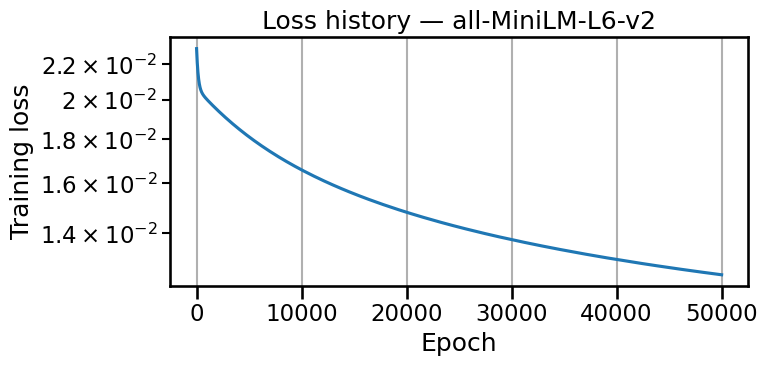

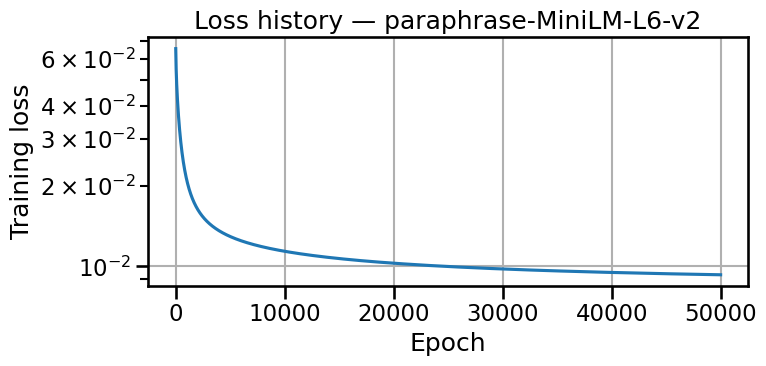

In [59]:
for model_name in embedding_models:
    loss_history = artifacts[model_name]["loss_history"]
    plt.figure(figsize=(8, 4))
    plt.plot(np.arange(len(loss_history)), loss_history)
    plt.yscale("log")
    plt.xlabel("Epoch")
    plt.ylabel("Training loss")
    plt.title(f"Loss history — {model_name}")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

## Step 5: Baseline head-to-head comparison

Now that both embedding models have been trained using the same linear PyTorch classifier pipeline, we compare them in several ways:

- overall metrics on train / test / holdout
- fine-label confusion matrices
- per-class F1 differences
- disagreement examples on the same test questions

This lets us separate **overall performance** from **where each embedding succeeds or fails**.


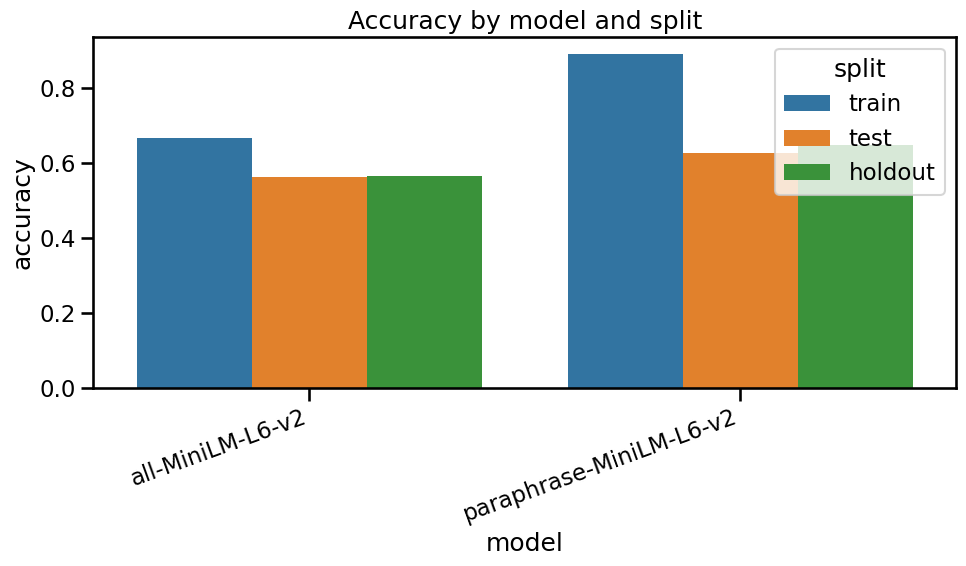

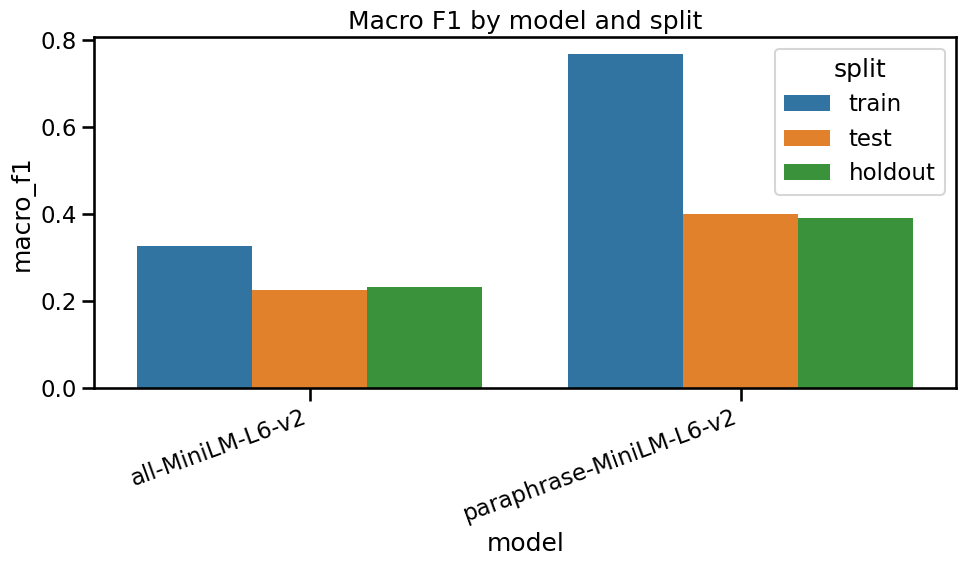

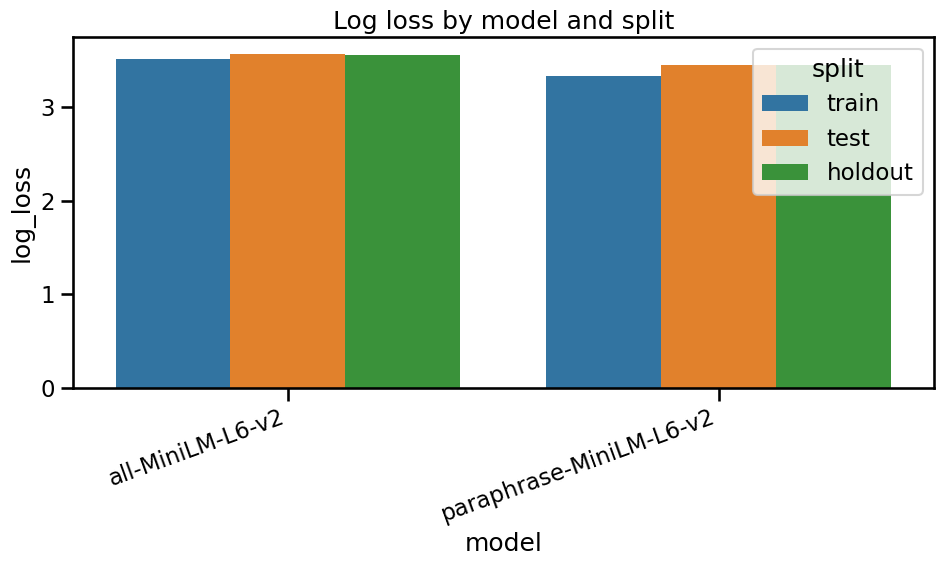

In [56]:
plot_metric_comparison(results_df, "accuracy", "Accuracy by model and split")
plot_metric_comparison(results_df, "macro_f1", "Macro F1 by model and split")
plot_metric_comparison(results_df, "log_loss", "Log loss by model and split")

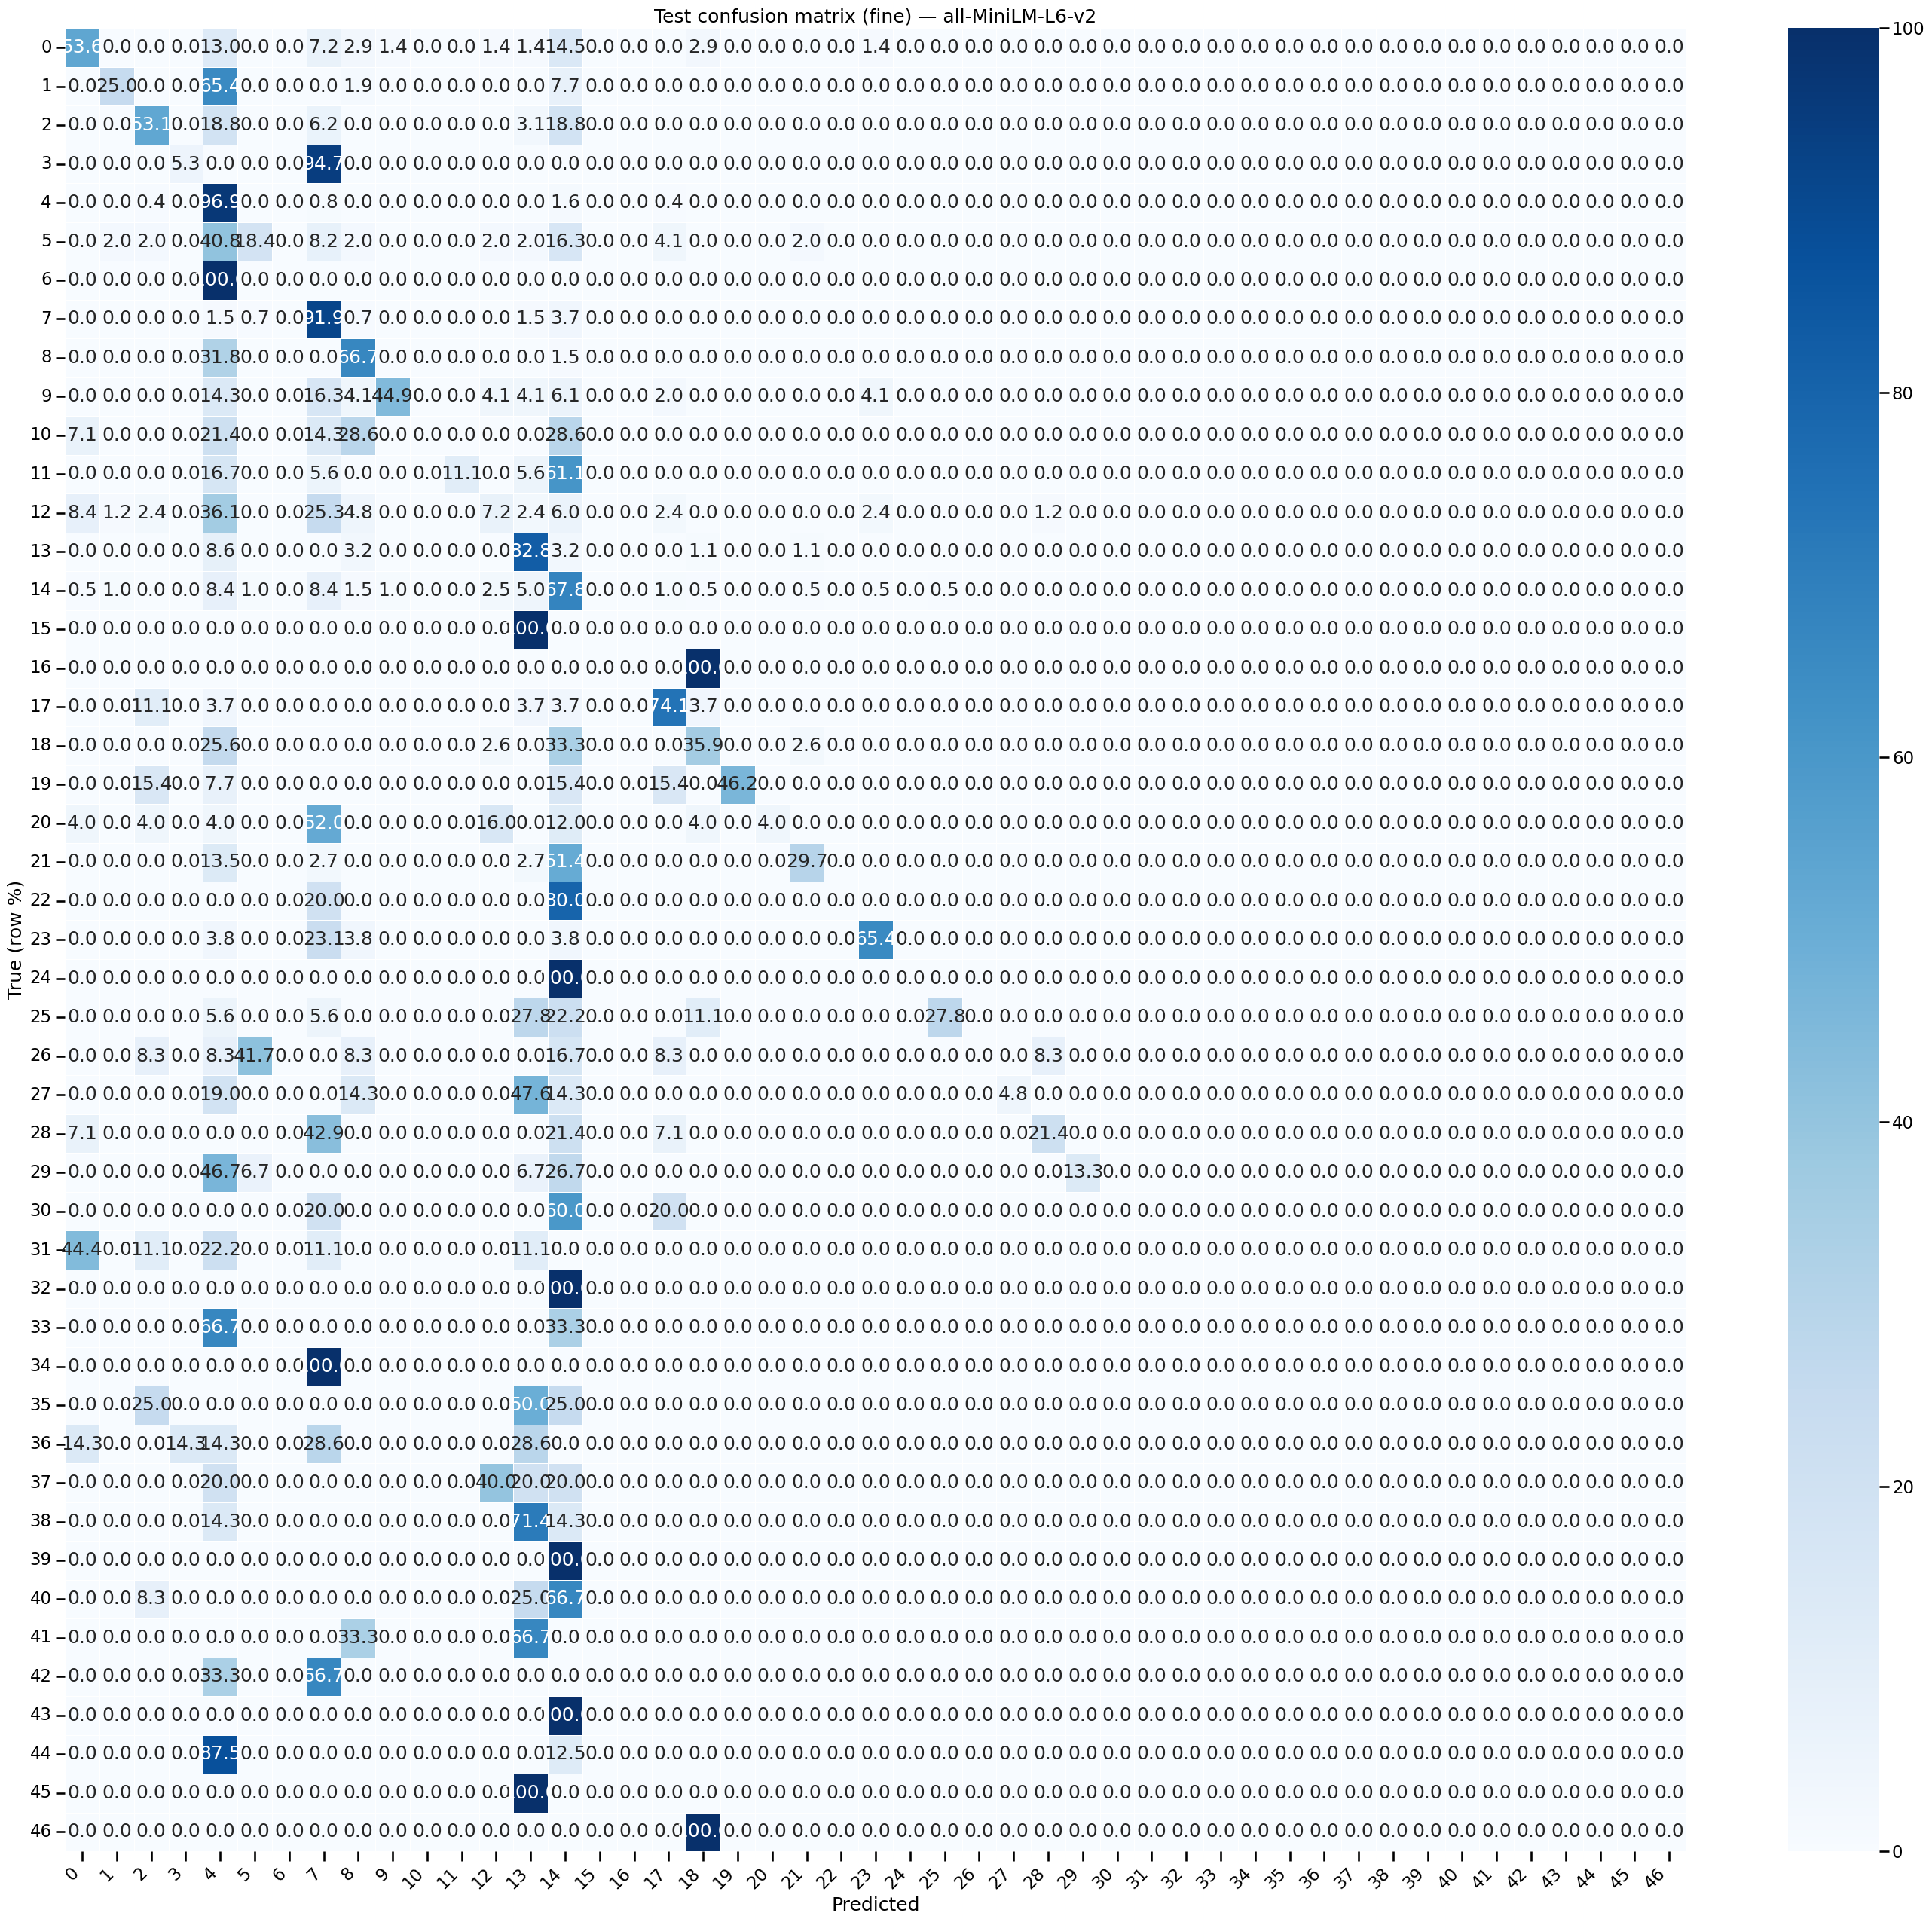

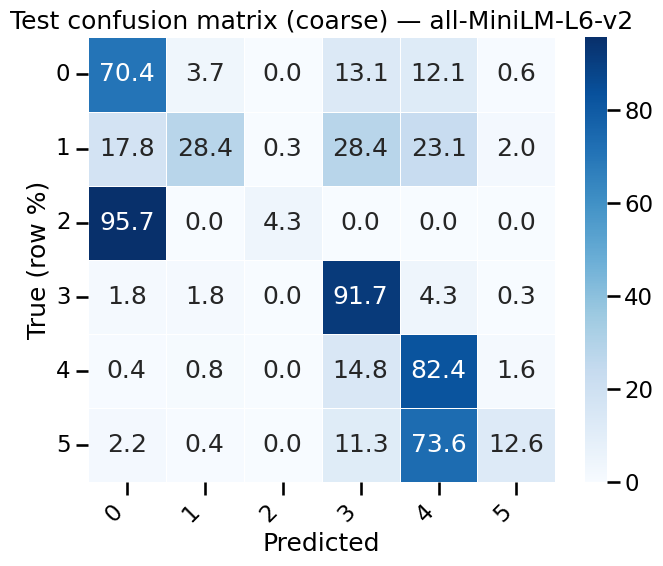

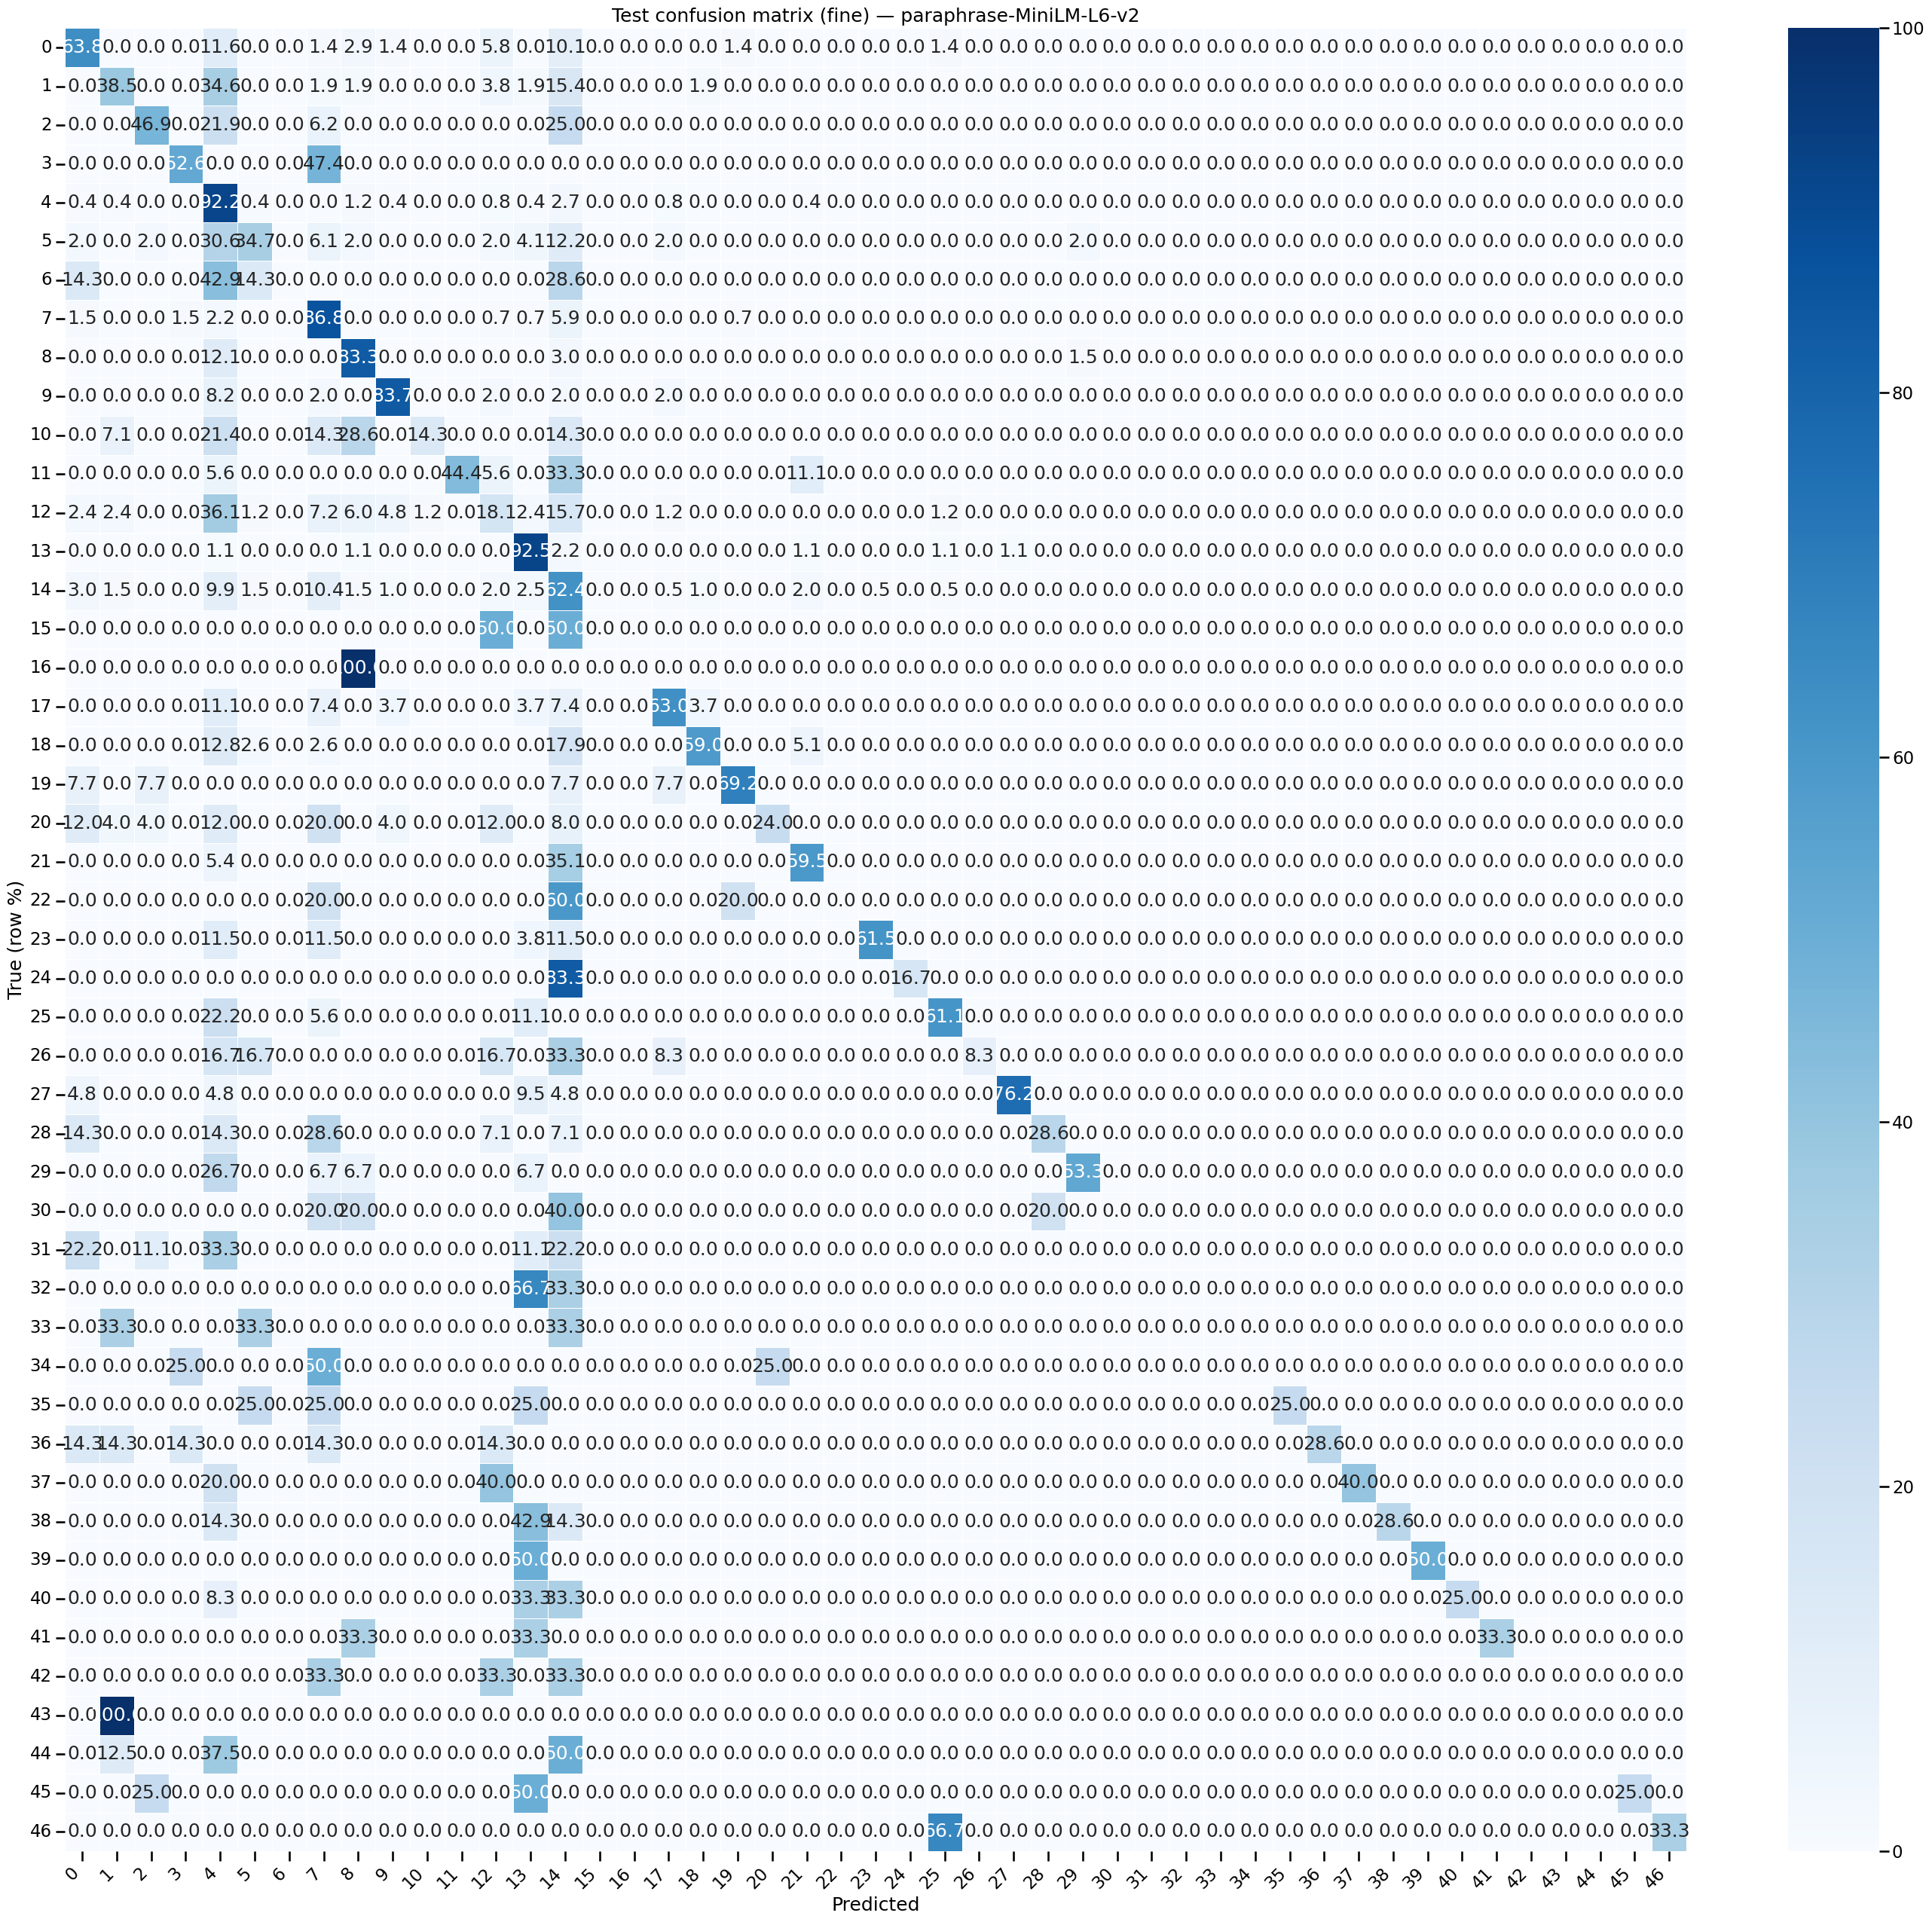

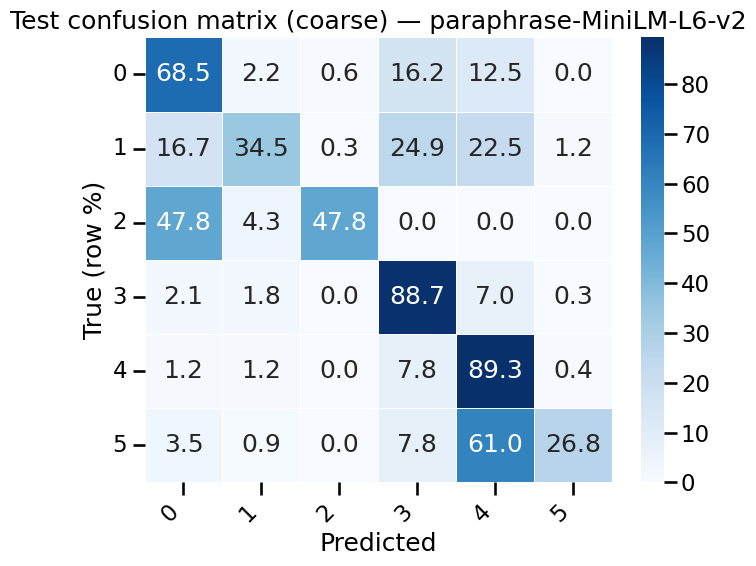

In [60]:
matrices_dir = Path("matrices")

for model_name in embedding_models:
    plot_conf_mat(
        artifacts[model_name]["y_test_idx"],
        artifacts[model_name]["test_pred_idx"],
        labels=np.arange(len(class_names)),
        title=f"Test confusion matrix (fine) — {model_name}",
        save_path=matrices_dir / f"baseline_{model_name}_fine.png"
    )

    # coarse view: map predicted fine label -> coarse label
    test_pred_coarse = pd.Series(artifacts[model_name]["test_pred_labels"]).map(fine_to_coarse).to_numpy()

    plot_conf_mat(
        y_test_coarse,
        test_pred_coarse,
        labels=class_names_coarse,
        title=f"Test confusion matrix (coarse) — {model_name}",
        save_path=matrices_dir / f"baseline_{model_name}_coarse.png"
    )

In [3]:
# Copy only the matrices created in this notebook into a separate folder for download
from pathlib import Path
import shutil

src_dir = Path('matrices')
dst_dir = Path('new_matrices')
dst_dir.mkdir(parents=True, exist_ok=True)

# newCodeBase writes baseline_{model}_fine/coarse.png -> 4 files total
patterns = ["baseline_*_fine.png", "baseline_*_coarse.png"]
copied = 0
for pattern in patterns:
    for img_path in src_dir.glob(pattern):
        shutil.copy2(img_path, dst_dir / img_path.name)
        copied += 1

print(f'Copied {copied} files to {dst_dir}')


Copied 4 files to new_matrices


In [4]:
# Combine the 4 matrices into a single PDF
from pathlib import Path
from PIL import Image

src_dir = Path('new_matrices')
pdf_path = src_dir / 'combined_matrices.pdf'

image_paths = sorted(src_dir.glob('baseline_*_*.png'))
if not image_paths:
    raise FileNotFoundError('No matrices found in new_matrices')

images = [Image.open(p).convert('RGB') for p in image_paths]
images[0].save(pdf_path, save_all=True, append_images=images[1:])

print(f'Wrote {pdf_path} with {len(images)} pages')


Wrote new_matrices/combined_matrices.pdf with 4 pages


model,label-fine,all-MiniLM-L6-v2,paraphrase-MiniLM-L6-v2,difference
46,46,0.000000,0.000000,0.000000
36,36,0.000000,0.000000,0.000000
35,35,0.000000,0.000000,0.000000
34,34,0.000000,0.000000,0.000000
33,33,0.000000,0.000000,0.000000
32,32,0.000000,0.000000,0.000000
31,31,0.000000,0.000000,0.000000
30,30,0.000000,0.000000,0.000000
27,27,0.000000,0.000000,0.000000
24,24,0.000000,0.000000,0.000000


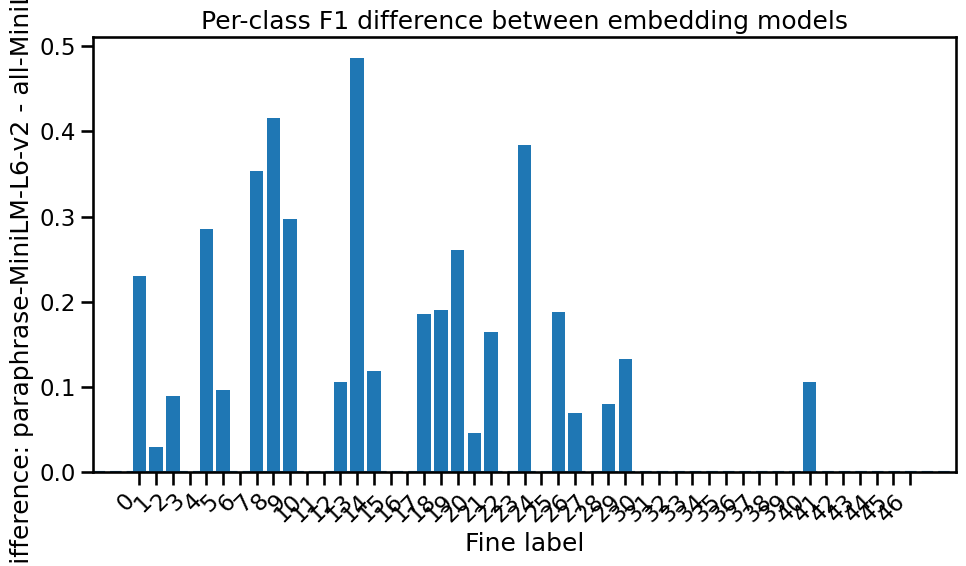

In [45]:
compare_df = (
    per_class_df
    .pivot(index="label-fine", columns="model", values="f1-score")
    .reset_index()
)

compare_df["difference"] = compare_df[embedding_models[1]] - compare_df[embedding_models[0]]
display(compare_df.sort_values("difference"))

plt.figure(figsize=(10, 6))
plt.bar(compare_df["label-fine"].astype(str), compare_df["difference"])
plt.axhline(0, linestyle="--")
plt.xlabel("Fine label")
plt.ylabel(f"F1 difference: {embedding_models[1]} - {embedding_models[0]}")
plt.title("Per-class F1 difference between embedding models")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [46]:
gen_view = results_df.pivot(index="model", columns="split", values=["accuracy", "macro_f1", "log_loss", "final_train_loss"])
display(gen_view)

accuracy                      macro_f1            \
split                     holdout      test     train   holdout      test   
model                                                                       
all-MiniLM-L6-v2         0.212030  0.221102  0.218414  0.015971  0.015934   
paraphrase-MiniLM-L6-v2  0.362567  0.347446  0.413306  0.107045  0.107769   

                                   log_loss                      \
split                       train   holdout      test     train   
model                                                             
all-MiniLM-L6-v2         0.015696  3.795844  3.796542  3.795519   
paraphrase-MiniLM-L6-v2  0.149726  3.636297  3.641718  3.607875   

                        final_train_loss                      
split                            holdout      test     train  
model                                                         
all-MiniLM-L6-v2                0.020072  0.020072  0.020072  
paraphrase-MiniLM-L6-v2         0.026636  0.026636  0.026636

In [47]:
for model_name in embedding_models:
    error_df = test_split_df.copy()
    error_df["pred"] = artifacts[model_name]["test_pred_labels"]
    error_df["correct"] = error_df["label-fine"] == error_df["pred"]

    print(f"\nSample mistakes for {model_name}")
    display(error_df.loc[~error_df["correct"], ["text", "label-fine", "pred"]].head(20))


Sample mistakes for all-MiniLM-L6-v2


,text,label-fine,pred
5301,What is the name given to the Islamic counterp...,20,14
5664,What province is Montreal in ?,11,4
5942,What is pectin ?,7,4
1978,What countries have the best math students ?,18,14
5304,What is Michael Jackson 's father 's name ?,4,7
5590,What position did Willie Davis play in baseball ?,6,4
2457,Who is Count Cinzano ?,12,4
3874,"What do Hank Aaron , Jimmy Stewart , and Howar...",12,4
2428,How did people respond to the idea of the firs...,0,4
1970,What 's the most popular contact lens color ?,19,14



Sample mistakes for paraphrase-MiniLM-L6-v2


,text,label-fine,pred
5301,What is the name given to the Islamic counterp...,20,12
5664,What province is Montreal in ?,11,14
1978,What countries have the best math students ?,18,21
5590,What position did Willie Davis play in baseball ?,6,4
2457,Who is Count Cinzano ?,12,4
3874,"What do Hank Aaron , Jimmy Stewart , and Howar...",12,4
2428,How did people respond to the idea of the firs...,0,7
1970,What 's the most popular contact lens color ?,19,33
4890,What is the difference between love and infatu...,12,7
2025,What is a fear of pregnancy ?,23,7


## Step 6: Diagnose successes and deficiencies in the embedding models

Instead of changing the split or retraining with extra examples, this section keeps the supervised learner fixed and asks:

- Which embedding model wins overall?
- Which fine labels are easier for one embedding than the other?
- What confusion patterns does each model show?
- On which exact questions do the two models disagree?
- Are the weaknesses concentrated in certain coarse categories?

This is closer to an embedding evaluation study: the downstream classifier is the same, so the main difference comes from the information captured by the embedding space.


In [48]:
test_results = (
    results_df[results_df["split"] == "test"]
    .sort_values(["accuracy", "macro_f1"], ascending=False)
    .reset_index(drop=True)
)

display(test_results)

summary_cols = ["model", "accuracy", "macro_f1", "log_loss", "final_train_loss", "embedding_time_sec"]
print("Test-set ranking:")
display(test_results[summary_cols])


,split,accuracy,macro_f1,log_loss,model,embed_time_train_sec,embed_time_test_sec,embed_time_holdout_sec,fit_time_sec,initial_train_loss,final_train_loss
0,test,0.347446,0.107769,3.641718,paraphrase-MiniLM-L6-v2,0.658278,0.842972,1.917226,0.785039,0.065001,0.026636
1,test,0.221102,0.015934,3.796542,all-MiniLM-L6-v2,1.396867,0.912962,1.976859,0.787280,0.022921,0.020072


Test-set ranking:


KeyError: "['embedding_time_sec'] not in index"

In [ ]:
head_to_head_df = (
    per_class_df
    .pivot(index="label-fine", columns="model", values="f1-score")
    .reset_index()
)

head_to_head_df["gap"] = head_to_head_df[embedding_models[1]] - head_to_head_df[embedding_models[0]]
head_to_head_df["abs_gap"] = head_to_head_df["gap"].abs()
head_to_head_df["winner"] = np.where(
    head_to_head_df["gap"] > 0,
    embedding_models[1],
    np.where(head_to_head_df["gap"] < 0, embedding_models[0], "tie")
)

print("Classes with the largest performance gaps:")
display(head_to_head_df.sort_values("abs_gap", ascending=False).head(15))

for model_name in embedding_models:
    print(f"\nTop classes for {model_name}")
    cols = ["label-fine", model_name]
    other = [m for m in embedding_models if m != model_name][0]
    tmp = head_to_head_df[["label-fine", model_name, other, "gap", "winner"]].copy()
    if model_name == embedding_models[0]:
        display(tmp.sort_values("gap").head(10))
    else:
        display(tmp.sort_values("gap", ascending=False).head(10))


In [ ]:
def top_confusion_pairs(y_true, y_pred, class_names, top_n=10):
    cm = confusion_matrix(y_true, y_pred, labels=np.arange(len(class_names)))
    rows = []
    for i in range(len(class_names)):
        for j in range(len(class_names)):
            if i == j:
                continue
            count = int(cm[i, j])
            if count > 0:
                rows.append({
                    "true_label": class_names[i],
                    "pred_label": class_names[j],
                    "count": count,
                })
    out = pd.DataFrame(rows)
    if out.empty:
        return out
    return out.sort_values(["count", "true_label", "pred_label"], ascending=[False, True, True]).head(top_n).reset_index(drop=True)

top_confusions = {}
for model_name in embedding_models:
    conf_df = top_confusion_pairs(
        artifacts[model_name]["y_test_idx"],
        artifacts[model_name]["test_pred_idx"],
        class_names,
        top_n=15
    )
    top_confusions[model_name] = conf_df
    print(f"\nTop fine-label confusions for {model_name}")
    display(conf_df)


In [ ]:
comparison_rows = []

for model_name in embedding_models:
    pred_labels = np.array(artifacts[model_name]["test_pred_labels"])
    correct = pred_labels == y_test_labels
    comparison_rows.append(pd.DataFrame({
        "text": X_test_text,
        "true_label": y_test_labels,
        "pred_label": pred_labels,
        "model": model_name,
        "correct": correct
    }))

long_compare_df = pd.concat(comparison_rows, ignore_index=True)

wide_pred_df = long_compare_df.pivot(index="text", columns="model", values="pred_label").reset_index()
wide_correct_df = long_compare_df.pivot(index="text", columns="model", values="correct").reset_index()

disagreement_df = test_split_df[["text", "label-fine", "label-coarse"]].drop_duplicates().merge(
    wide_pred_df, on="text"
).merge(
    wide_correct_df, on="text", suffixes=("_pred", "_correct")
)

model_a, model_b = embedding_models

disagreement_df["models_disagree"] = disagreement_df[model_a + "_pred"] != disagreement_df[model_b + "_pred"]
disagreement_df["a_only_correct"] = disagreement_df[model_a + "_correct"] & ~disagreement_df[model_b + "_correct"]
disagreement_df["b_only_correct"] = disagreement_df[model_b + "_correct"] & ~disagreement_df[model_a + "_correct"]
disagreement_df["both_wrong"] = (~disagreement_df[model_a + "_correct"]) & (~disagreement_df[model_b + "_correct"])
disagreement_df["both_correct"] = disagreement_df[model_a + "_correct"] & disagreement_df[model_b + "_correct"]

head_to_head_counts = pd.Series({
    "both_correct": int(disagreement_df["both_correct"].sum()),
    f"{model_a}_only_correct": int(disagreement_df["a_only_correct"].sum()),
    f"{model_b}_only_correct": int(disagreement_df["b_only_correct"].sum()),
    "both_wrong": int(disagreement_df["both_wrong"].sum()),
    "models_disagree": int(disagreement_df["models_disagree"].sum()),
}).to_frame("count")

display(head_to_head_counts)

print(f"\nExamples where {model_a} is right and {model_b} is wrong")
display(
    disagreement_df.loc[disagreement_df["a_only_correct"],
                        ["text", "label-fine", "label-coarse", model_a + "_pred", model_b + "_pred"]].head(15)
)

print(f"\nExamples where {model_b} is right and {model_a} is wrong")
display(
    disagreement_df.loc[disagreement_df["b_only_correct"],
                        ["text", "label-fine", "label-coarse", model_a + "_pred", model_b + "_pred"]].head(15)
)

print("\nExamples where both models are wrong in different ways")
display(
    disagreement_df.loc[disagreement_df["models_disagree"] & disagreement_df["both_wrong"],
                        ["text", "label-fine", "label-coarse", model_a + "_pred", model_b + "_pred"]].head(15)
)


## Step 7: Coarse-category analysis

Fine-label results tell us which exact classes are difficult, but coarse-category analysis can reveal whether one embedding is better at separating broader semantic groups such as **HUM**, **LOC**, **NUM**, **DESC**, **ENTY**, or **ABBR**.


In [ ]:
def per_group_accuracy(df, true_col, pred_col, group_col):
    out = (
        df.assign(correct=df[true_col] == df[pred_col])
          .groupby(group_col)["correct"]
          .agg(["mean", "count"])
          .reset_index()
          .rename(columns={"mean": "accuracy", "count": "n"})
    )
    return out

coarse_rows = []
for model_name in embedding_models:
    temp = test_split_df.copy()
    temp["pred_label_fine"] = artifacts[model_name]["test_pred_labels"]
    temp["pred_label_coarse"] = temp["pred_label_fine"].map(fine_to_coarse)

    coarse_acc = per_group_accuracy(temp, "label-coarse", "pred_label_coarse", "label-coarse")
    coarse_acc["model"] = model_name
    coarse_rows.append(coarse_acc)

coarse_compare_df = pd.concat(coarse_rows, ignore_index=True)
display(coarse_compare_df.sort_values(["label-coarse", "model"]))

plt.figure(figsize=(10, 6))
sns.barplot(data=coarse_compare_df, x="label-coarse", y="accuracy", hue="model")
plt.title("Coarse-category accuracy by embedding model")
plt.ylim(0, 1.0)
plt.tight_layout()
plt.show()


In [ ]:
success_failure_summary = head_to_head_df[["label-fine", "winner", "abs_gap"]].copy()
success_failure_summary["strong_difference"] = success_failure_summary["abs_gap"] >= success_failure_summary["abs_gap"].median()

print("Classes won by each model:")
display(success_failure_summary["winner"].value_counts(dropna=False).to_frame("num_classes"))

print("\nMost clearly separated successes / deficiencies:")
display(success_failure_summary.sort_values("abs_gap", ascending=False).head(20))

for model_name in embedding_models:
    won = success_failure_summary.loc[success_failure_summary["winner"] == model_name, "label-fine"].tolist()
    print(f"\nClasses where {model_name} has the higher test F1:")
    print(won[:20], "..." if len(won) > 20 else "")


In [ ]:
print("Suggested interpretation questions:")
print("1. Does one embedding win mostly by a small amount everywhere, or by a lot on a few classes?")
print("2. Are the major errors within the same coarse family or across coarse families?")
print("3. Do disagreement examples suggest one embedding captures paraphrase/semantics better, while the other captures wording patterns better?")
print("4. Which weak classes would be the highest-priority targets for future data collection or prompt-style augmentation?")


## Optional: custom examples

In [ ]:
custom_examples = [
    "Who invented the telescope?",
    "What is the capital of Peru?",
    "When was the internet invented?",
    "Where is the Sahara Desert located?",
]

def predict_custom_examples(model_name, texts, artifact_dict):
    embedder = SentenceTransformer(model_name)
    X_custom = embedder.encode(texts, convert_to_numpy=True, show_progress_bar=False)
    X_custom_tensor = torch.tensor(X_custom, dtype=torch.float32)

    raw_scores, pred_idx = pytorch_model_multiclass_inference(artifact_dict["trained_model"], X_custom_tensor)
    probs = predict_proba_from_scores(raw_scores)

    pred_labels = [class_names[i] for i in pred_idx]
    return pd.DataFrame({
        "text": texts,
        "predicted_label_fine": pred_labels,
        "confidence": probs.max(axis=1),
    })

for model_name in embedding_models:
    print(f"\nCustom predictions — {model_name}")
    display(predict_custom_examples(model_name, custom_examples, post_artifacts[model_name]))

## Short conclusion template

This notebook now follows the codex framing more directly while shifting the **research focus**:

- each question embedding is treated as an input vector `x in R^d`,
- each fine label is encoded as a one-hot target `y in R^k`,
- a linear PyTorch model learns the map from embeddings to label scores,
- training uses gradient descent,
- and inference uses `argmax` over the model output. fileciteturn4file2 fileciteturn3file0

But the main analysis question is now:

**Given the same linear classifier, what do the two embedding spaces do well, and where does each one break down?**

That makes the notebook much more about **embedding-model successes and deficiencies** than about changing the split or showing improvement after retraining.
